In [1]:
import numpy as np
from scipy.stats import beta, norm, binom

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

# Prior predictive check

In [10]:
# prior
ps = np.linspace(0, 1, 101)
prior_a = 0.01  # 1 or 0.1
prior_b = 10

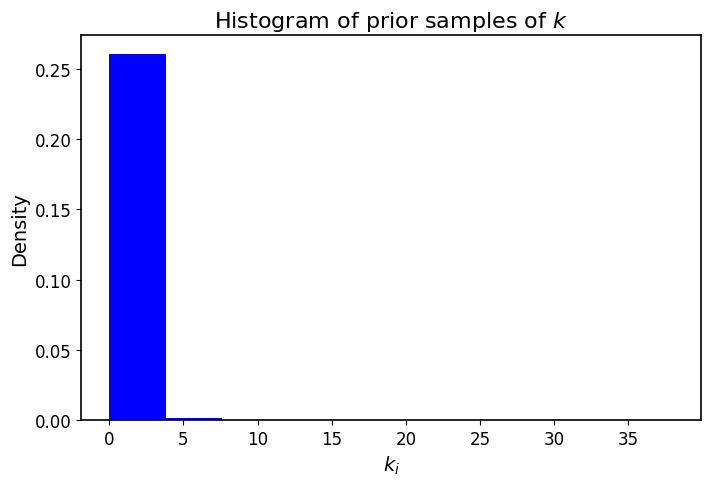

In [11]:
seed = 0
prior_p_samples = beta.rvs(prior_a, prior_b, size=10_000, random_state=seed)
prior_k_samples = binom.rvs(100, prior_p_samples, random_state=seed)

plt.figure(figsize=(8, 5))

plt.hist(prior_k_samples, color="b", density=True)

plt.xlabel(r"$k_i$")
plt.ylabel("Density")
plt.title(r"Histogram of prior samples of $k$")

plt.show()

# Posterior predictive check

In [12]:
# observed data
k = 3  # number of tea drinkers
n = 5  # number of people surveyed

# posterior
post_a = prior_a + k
post_b = prior_b + (n - k)

post_a, post_b

(3.01, 12)

In [21]:
(np.unique(post_k_samples, return_counts=True)[1] / 10_000)[:4]

array([0.3759, 0.3608, 0.1813, 0.0652])

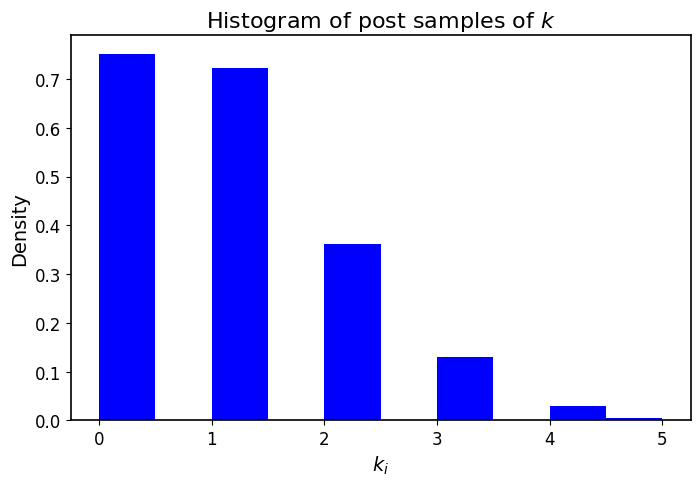

In [13]:
seed = 0
post_p_samples = beta.rvs(post_a, post_b, size=10_000, random_state=seed)
post_k_samples = binom.rvs(5, post_p_samples, random_state=seed)

plt.figure(figsize=(8, 5))

plt.hist(post_k_samples, color="b", density=True)

plt.xlabel(r"$k_i$")
plt.ylabel("Density")
plt.title(r"Histogram of post samples of $k$")

plt.show()

# illustrations

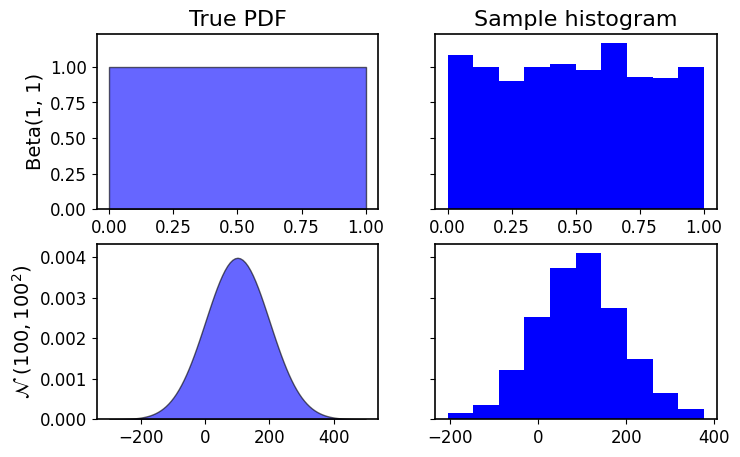

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5), sharey="row")

xs = np.linspace(0, 1, 101)
prior_pdf = beta.pdf(xs, prior_a, prior_b)
prior_samples = beta.rvs(prior_a, prior_b, size=1000, random_state=0)

ax[0, 0].fill_between(xs, prior_pdf, color="blue", edgecolor="k", alpha=0.6)
ax[0, 1].hist(prior_samples, density=True, color="blue")

ax[0, 0].set_xlabel(r'$p$')
ax[0, 1].set_xlabel(r'$p$')

ax[0, 0].set_ylabel("Beta(1, 1)")
ax[1, 0].set_ylabel(r"$\mathcal{N}~(100, 100^2)$")
ax[0, 0].set_title("True PDF")
ax[0, 1].set_title("Sample histogram")

mu = 100
sigma2 = 100**2

mus = np.linspace(-300, 500, 101)
prior_pdf = norm.pdf(mus, mu, np.sqrt(sigma2))
prior_samples = norm.rvs(mu, np.sqrt(sigma2), size=1000, random_state=0)

ax[1, 0].fill_between(mus, prior_pdf, color="blue", edgecolor="k", alpha=0.6)
ax[1, 1].hist(prior_samples, density=True, color="blue")

plt.show()